# Mini Project Notebook: Employee Attrition Prediction
## PRASHANTH KANNADAGULI
### SENIOR DATA SCIENCE TRAINER

## Problem Statement

To predict employee attrition using CatBoost and XgBoost

## Learning Objectives

At the end of the experiment, you will be able to

* explore the employee attrition dataset
* apply CatBoost and XgBoost on the dataset
* tune the model hyperparameters to improve accuracy
* evaluate the model using suitable metrics


## Introduction

Employee attrition is the gradual reduction in employee numbers. Employee attrition happens when the size of your workforce diminishes over time. This means that employees are leaving faster than they are hired. Employee attrition happens when employees retire, resign, or simply aren't replaced.
Although employee attrition can be company-wide, it may also be confined to specific parts of a business.

Employee attrition can happen for several reasons. These include unhappiness about employee benefits or the pay structure, a lack of employee development opportunities, and even poor conditions in the workplace.

To know more about the factors that lead to employee attrition, refer [here](https://www.betterup.com/blog/employee-attrition#:~:text=Employee%20attrition%20is%20the%20gradual,or%20simply%20aren't%20replaced).


**Gradient Boosted Decision Trees**

* Gradient boosted decision trees (GBDTs) are one of the most important machine learning models.

* GBDTs originate from AdaBoost, an algorithm that ensembles weak learners and uses the majority vote, weighted by their individual accuracy, to solve binary classification problems. The weak learners in this case are decision trees with a single split, called decision stumps.

* Some of the widely used gradient boosted decision trees are XgBoost, CatBoost and LightGBM.

## Dataset

The dataset used for this mini-project is [HR Employee Attrition dataset](https://data.world/aaizemberg/hr-employee-attrition). This dataset is synthetically created by IBM data scientists. There are 35 features and 1470 records.

There are numerical features such as:

* Age
* DistanceFromHome
* EmployeeNumber
* PerformanceRating

There are several categorical features such as:
* JobRole
* EducationField
* Department
* BusinessTravel

Dependent or target feature is 'attrition' which has values as Yes/No.

### Install CatBoost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -qq install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.6 MB/s eta 0:00:00


### Import Required Packages

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, metrics
import warnings
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 100)
%matplotlib inline

## Load the Dataset

**Exercise 1: Read the dataset**

**Hint:** pd.read_csv()

In [ ]:
# read the dataset
# YOUR CODE HERE
df = pd.read_csv('/content/drive/MyDrive/mini project 4/hr_employee_attrition_train (1).csv')
df.head()

,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,over18,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,1,1888,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,Y,No,13,3,4,80,2,10,2,2,9,8,3,8,No
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,1,757,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,Y,No,11,3,4,80,0,10,2,3,5,1,4,3,No
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,1,1310,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,Y,No,13,3,1,80,0,6,2,3,5,2,0,3,Yes
3,26,Travel_Rarely,933,Sales,1,3,Life Sciences,1,476,3,Male,57,3,2,Sales Executive,3,Married,5296,20156,1,Y,No,17,3,2,80,1,8,3,3,8,7,7,7,No
4,40,Travel_Rarely,329,Research & Development,1,4,Life Sciences,1,1361,2,Male,88,3,1,Laboratory Technician,2,Married,2387,6762,3,Y,No,22,4,3,80,1,7,3,3,4,2,0,3,No


In [ ]:
# Check the shape of dataframe.
# YOUR CODE HERE
df.shape

(1170, 35)

There can be more than one file to read as this is introduced as a competition, dataset has one file for training the model. Their can be other files as one containing the test features and the other can be the true labels.

## Data Exploration

- Check for missing values
- Check for consistent data type across a feature
- Check for outliers or inconsistencies in data columns
- Check for correlated features
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships? Making correlation heatmaps makes it easy to identify possible collinearity

**Exercise 2: Create a `List` of numerical and categorical columns. Display a statistical description of the dataset. Remove missing values (if any)**

**Hint:** Use `for` to iterate through each column.

In [ ]:
# YOUR CODE HERE
# Lists for numerical and categorical columns
numerical_cols = []
categorical_cols = []

# Identify column types
for col in df.columns:
    if df[col].dtype == 'object':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# Statistical description
df.describe(include='all')

# Check and remove missing values
print("\nMissing Values:\n", df.isnull().sum())
df.dropna(inplace=True)


Numerical Columns:
['age', 'dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']

Categorical Columns:
['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime', 'attrition']

Missing Values:
 age                         0
businesstravel              0
dailyrate                   0
department                  0
distancefromhome            0
education                   0
educationfield              0
employeecount               0
employeenumber              0
environmentsatisfaction     0
gender               

First, we want to get a sense of our data:
- What features have the most divergent distributions based on target class
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships, making correlation heatmaps makes it easy to identify possible colinearity

### Check for outliers

**Exercise 3: Create a box plot to check for outliers**

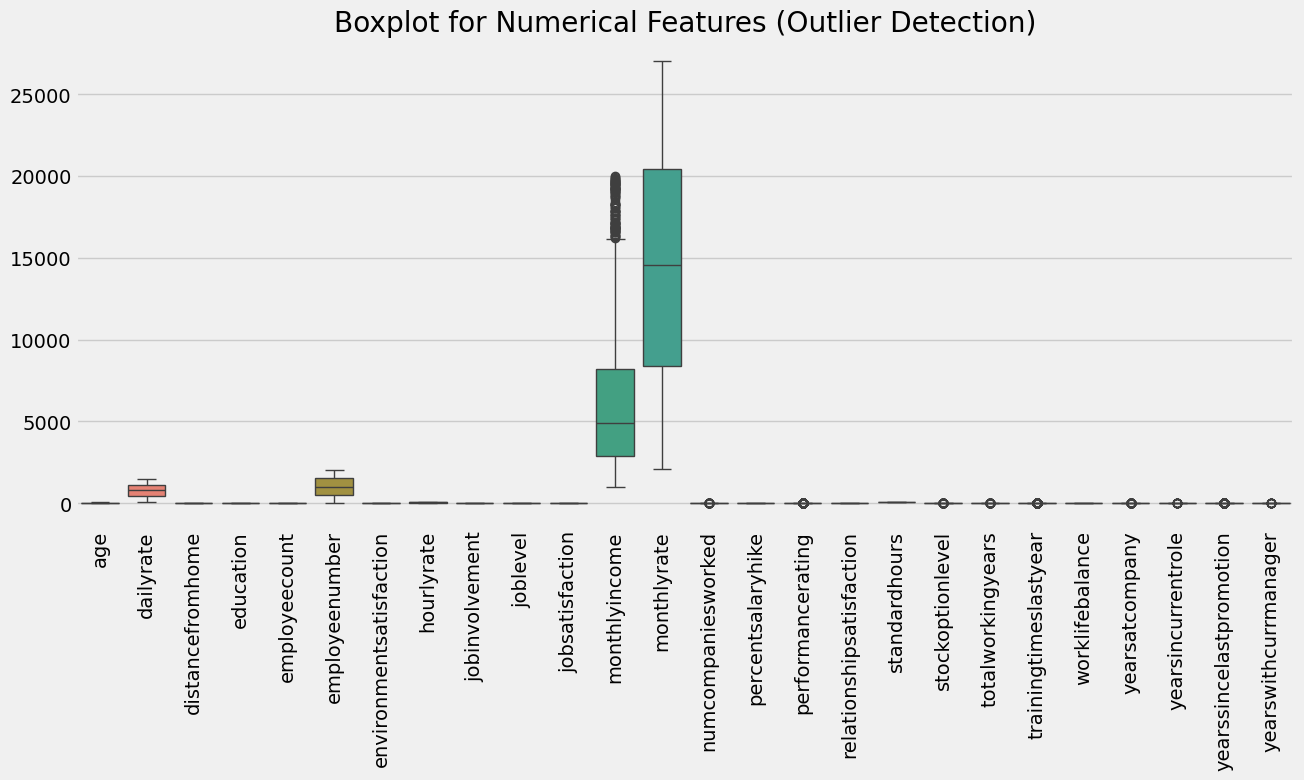

In [ ]:
# Check for outliers
# YOUR CODE HERE
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Numerical Features (Outlier Detection)")
plt.show()


### Handling outliers

**Exercise 4: Use lower bound as 25% and upper bound as 75% to handle the outliers**

In [ ]:
# YOUR CODE HERE
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled using IQR method.")


Outliers handled using IQR method.


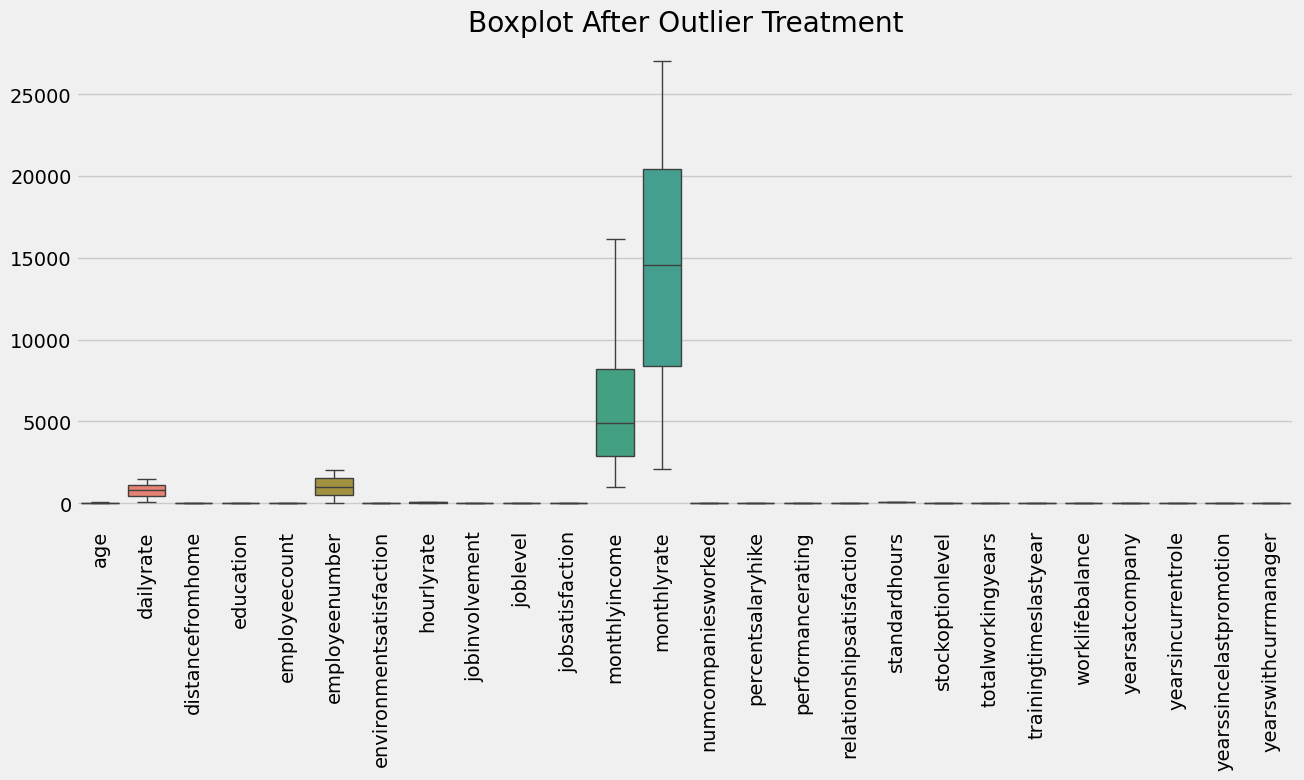

In [ ]:
# Recheck for outliers
# YOUR CODE HERE
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Treatment")
plt.show()


### Target label imbalance

**Exercise 5: Check if there is an imbalance in target label**

**Hint:** Use value_counts()

In [ ]:
# Count of unique values in Attrition column
# YOUR CODE HERE
df['attrition'].value_counts()

,count
attrition,
No,981
Yes,189


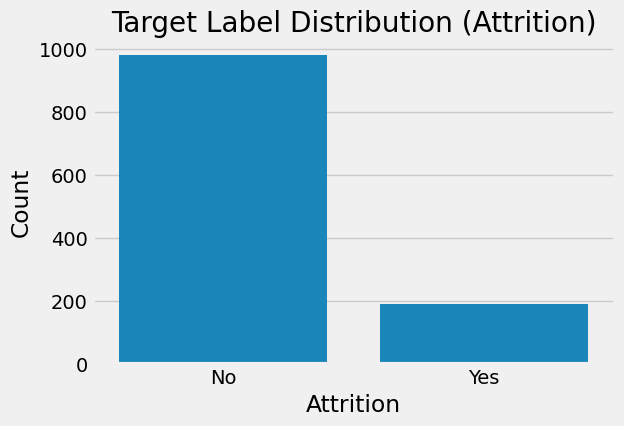

In [ ]:
# Plot barplot to visualize balance/imbalance
# YOUR CODE HERE
plt.figure(figsize=(6,4))
sns.countplot(x='attrition', data=df)
plt.title("Target Label Distribution (Attrition)")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()


If there is any imbalance in the dataset then a few techniques can be utilised (optional):
1. SMOTE
2. Cross Validation
3. Regularizing the model's parameters

###Plot pairplot

**Exercise 6: Visualize the relationships between the predictor variables and the target variable using a pairplot**

**Hint:** Use sns.pairplot

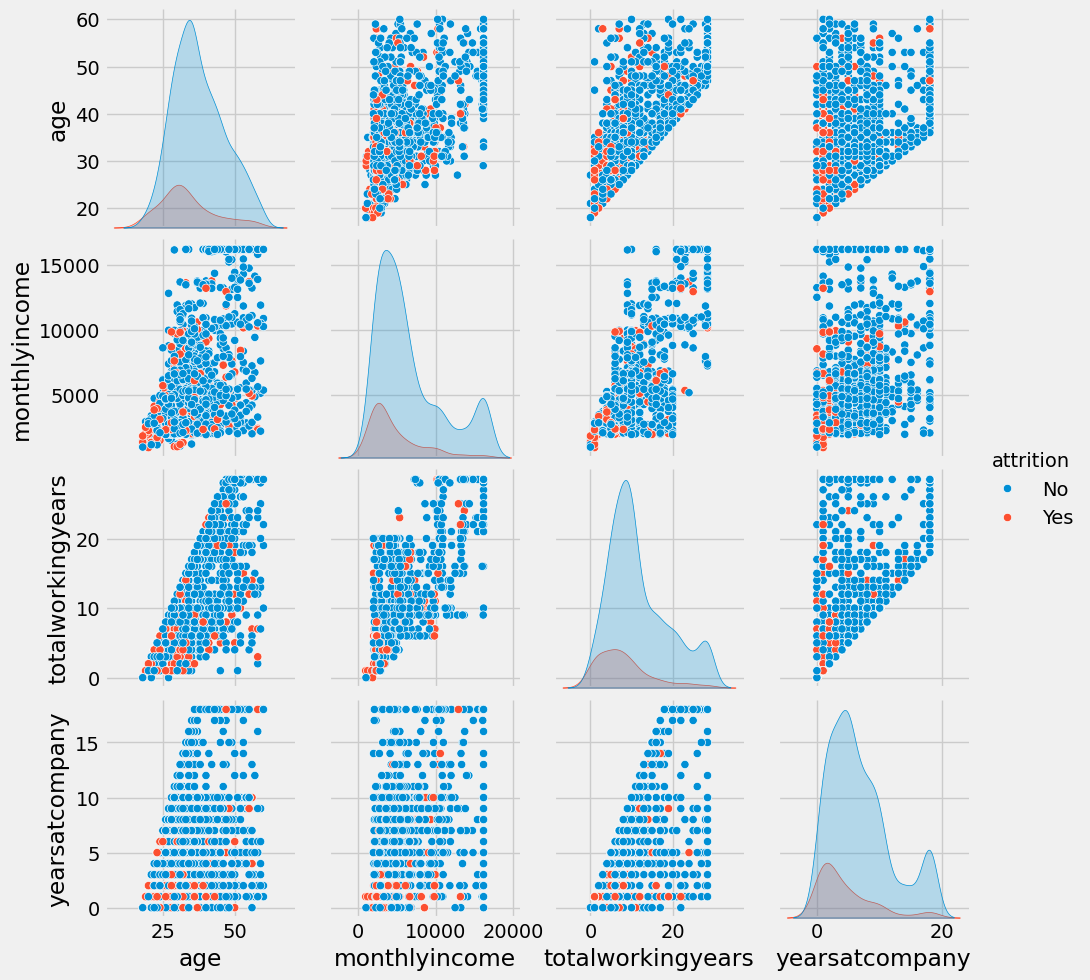

In [ ]:
# Visualize a pairplot with relevant features
# YOUR CODE HERE
pairplot_cols = ['age', 'monthlyincome', 'totalworkingyears',
                 'yearsatcompany', 'attrition']

sns.pairplot(df[pairplot_cols], hue='attrition')
plt.show()

### Explore Correlation

- Plotting the Heatmap

**Exercise 7: Visualize the correlation among IBM employee attrition numerical features using a heatmap**

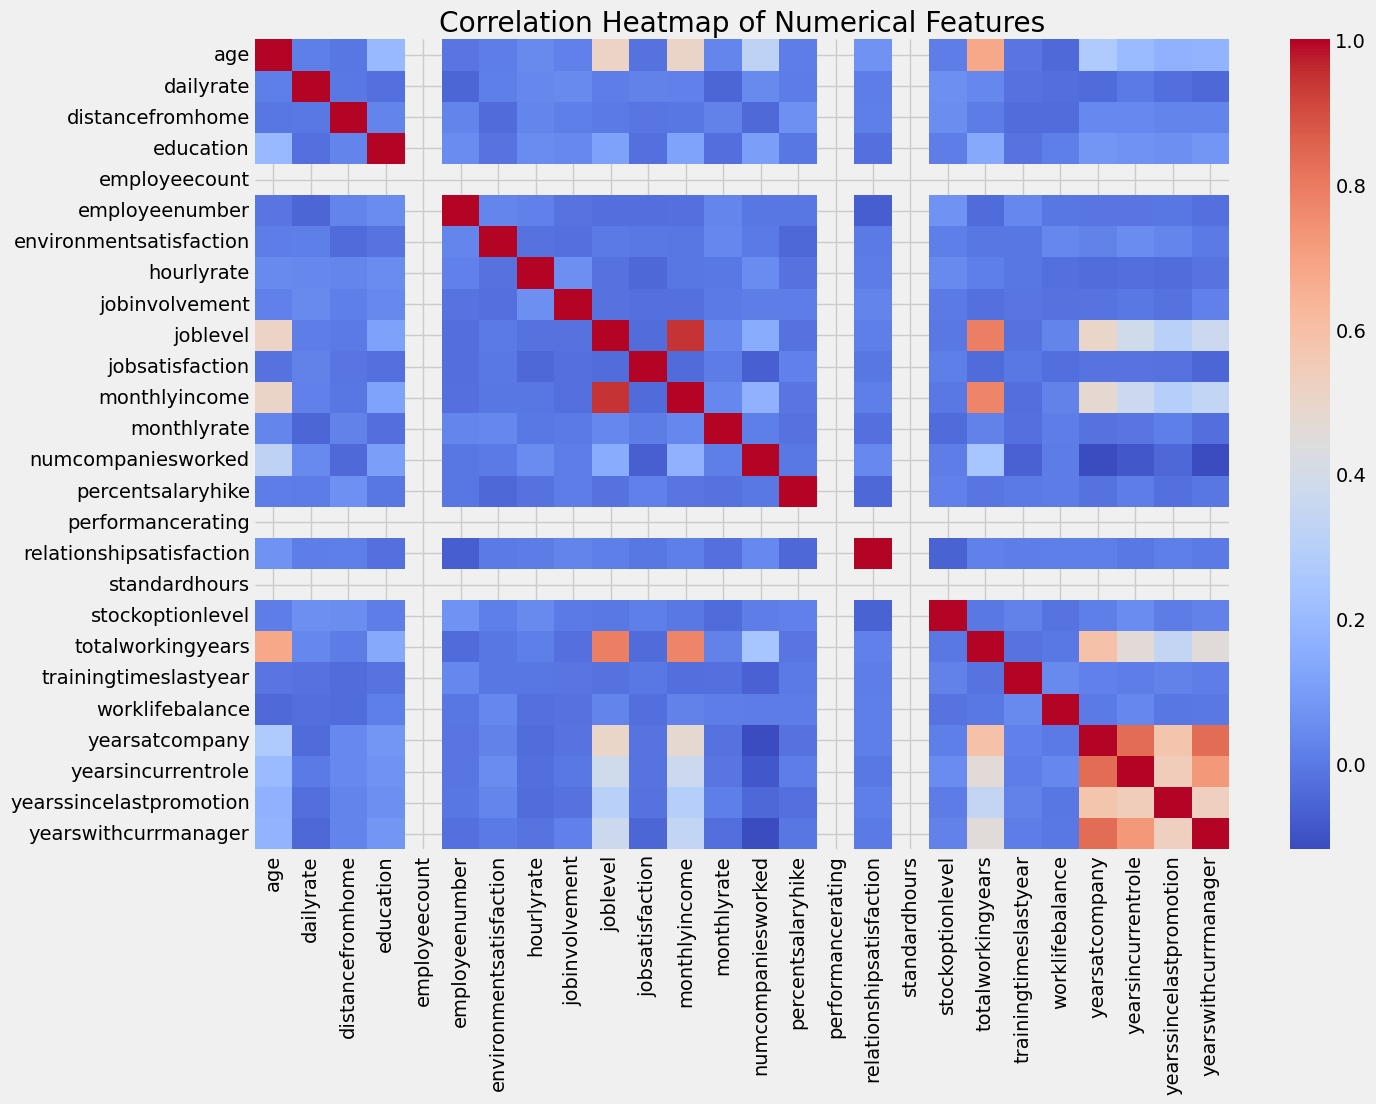

In [ ]:
# Visualize heatmap
# YOUR CODE HERE
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Comment on the observations made with the pairplot and heatmap

Insights from the Pair Plot:

Employees earning higher monthly salaries and having greater overall work experience are less likely to leave the organization.

Attrition is more common among younger employees compared to older ones.

The two classes show some level of distinction, although the relationship is not strictly linear.

Insights from the Correlation Heatmap:

Age has a strong positive relationship with total years of work experience.

Years spent at the current company show a moderate association with total working years.

There is no evidence of severe multicollinearity, indicating the data is appropriate for tree-based models.

### Preparing the test feature space
* Remove outliers if any
* Handle the categorical feature if required
* Other processing steps can also be followed.

In [ ]:

# Make a clean copy of the dataframe after outlier handling
df_processed = df.copy()

# Separate target and features
X = df_processed.drop('attrition', axis=1)
y = df_processed['attrition']

# Identify categorical columns (excluding target)
cat_features = X.select_dtypes(include='object').columns.tolist()

print("Categorical Features:")
print(cat_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Categorical Features:
['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime']
Training set shape: (936, 34)
Test set shape: (234, 34)


Optional:
Use `Hyperopt`, a hyperparameter tuning technique to identify the best set of parameters.



In the notebook, data processing is done separately for different models.
Considering the fact that different models may require data in different format and in turn different processes may be followed to process the data.

If the processing steps followed for the models are same, data processing can also be done once.

## Apply CatBoost

Catboost was released in 2017 by Yandex, showing, by their benchmark to be faster in prediction, better in accuracy, and easier to use for categorical data across a series of GBDT tasks. Additional capabilities of catboost include plotting feature interactions and object (row) importance.

[Here](https://catboost.ai/en/docs/) is the official documentation of CatBoost

### Data Processing for CatBoost

**Exercise 8: Data processing for CatBoost**
* **Copy the dataframe that was created after removing the outliers**
* **Handle the categorical features if required**
* **Create target column and feature space**

**Hint:** Column containing the information on attrition will be the target column.

In [ ]:
# Copy the data
# YOUR CODE HERE
df_cb = df.copy()

In [ ]:
# Target Column
# YOUR CODE HERE
y_cb = df_cb['attrition']

In [ ]:
# Feature Space
# YOUR CODE HERE
X_cb = df_cb.drop('attrition', axis=1)

# Identify categorical features for CatBoost
cat_features = X_cb.select_dtypes(include='object').columns.tolist()

print("Categorical Features for CatBoost:")
print(cat_features)

Categorical Features for CatBoost:
['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime']


### Model Definition

**Exercise 9: Define, train the model and display the results**

**Hint:**
* Use CatBoostClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model. Refer [here](https://catboost.ai/en/docs/concepts/speed-up-training) to see some ways to speedup CatBoost training.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [ ]:
# Create CatBoost model
# YOUR CODE HERE
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)


In [ ]:
# Model training
# YOUR CODE HERE
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_cb, y_cb, test_size=0.2, random_state=42, stratify=y_cb
)

# Model training
cat_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features
)

### Model performance

In [ ]:
# Model performance on all sets
# YOUR CODE HERE
y_train_pred = cat_model.predict(X_train_cb)
y_test_pred = cat_model.predict(X_test_cb)

# Prediction probabilities
y_train_prob = cat_model.predict_proba(X_train_cb)[:, 1]
y_test_prob = cat_model.predict_proba(X_test_cb)[:, 1]

# Metrics
print("CATBOOST MODEL PERFORMANCE\n")

print("Training Accuracy:", accuracy_score(y_train_cb, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test_cb, y_test_pred))

print("\nTraining F1 Score:", f1_score(y_train_cb, y_train_pred, pos_label='Yes'))
print("Test F1 Score:", f1_score(y_test_cb, y_test_pred, pos_label='Yes'))

print("\nTraining ROC-AUC:", roc_auc_score(y_train_cb, y_train_prob))
print("Test ROC-AUC:", roc_auc_score(y_test_cb, y_test_prob))

CATBOOST MODEL PERFORMANCE

Training Accuracy: 1.0
Test Accuracy: 0.8589743589743589

Training F1 Score: 1.0
Test F1 Score: 0.37735849056603776

Training ROC-AUC: 1.0
Test ROC-AUC: 0.7743018259935553


## Apply XGBoost

XGBoost is a workhorse gradient boosted decision tree algorithm. Its been around since 2014 and has come to dominate the Kaggle and data science community. XGB introduced gradient boosting where new models are fit to the residuals of prior models and then added together, using a gradient descent algorithm to minimize the loss.

Read [here](https://xgboost.readthedocs.io/en/stable/parameter.html) on XGBoost parameters.

Refer [here](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) for the official documentation of XGBoost classifier.

### Data Processing for XGBoost


**Exercise 10: Data Processing for XGBoost**
* **Copy the dataframe after the outliers were removed.**
* **Handle the categorical features if required**
* **Create target column and feature space**

In [ ]:
# Copy dataframe
# YOUR CODE HERE
df_xgb = df.copy()

**Hint:** Use pd.get_dummies

In [ ]:
# Handling categorical features
# YOUR CODE HERE
df_xgb_dummies = pd.get_dummies(df_xgb, drop_first=True)

In [ ]:
# Concat the dummy variables to actual dataframe and remove initial categorical columns
# YOUR CODE HERE
df_xgb_final = df_xgb_dummies.copy()


When creating the dummy variables, the name of attrition column was changed, rename to 'attrition' again.

**Hint:** Use .rename

In [ ]:
# Rename target column
# YOUR CODE HERE
if 'attrition_Yes' in df_xgb_final.columns:
    df_xgb_final.rename(columns={'attrition_Yes': 'attrition'}, inplace=True)


In [ ]:
# Feature Space
# YOUR CODE HERE
X_xgb = df_xgb_final.drop('attrition', axis=1)


# Targer label
y_xgb = df_xgb_final['attrition']

### Model Definition

**Exercise 11: Define, train the model and display the results**

**Hint:**
* Use XGBClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [ ]:
# Create XGBoost classifier model
# YOUR CODE HERE
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
# Model training
# YOUR CODE HERE
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)


xgb_model.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Performance

In [ ]:
# Model performance on all sets
# YOUR CODE HERE
y_train_pred_xgb = xgb_model.predict(X_train_xgb)
y_test_pred_xgb = xgb_model.predict(X_test_xgb)

# Prediction probabilities
y_train_prob_xgb = xgb_model.predict_proba(X_train_xgb)[:, 1]
y_test_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Metrics
print("XGBOOST MODEL PERFORMANCE\n")

print("Training Accuracy:", accuracy_score(y_train_xgb, y_train_pred_xgb))
print("Test Accuracy:", accuracy_score(y_test_xgb, y_test_pred_xgb))

print("\nTraining F1 Score:", f1_score(y_train_xgb, y_train_pred_xgb))
print("Test F1 Score:", f1_score(y_test_xgb, y_test_pred_xgb))

print("\nTraining ROC-AUC:", roc_auc_score(y_train_xgb, y_train_prob_xgb))
print("Test ROC-AUC:", roc_auc_score(y_test_xgb, y_test_prob_xgb))


## Apply LightGBM

LightGBM is an open-source GBDT framework created by Microsoft as a fast and scalable alternative to XGB and GBM. By default LightGBM will train a Gradient Boosted Decision Tree (GBDT), but it also supports random forests, Dropouts meet Multiple Additive Regression Trees (DART), and Gradient Based One-Side Sampling (Goss).

To know more about LightGBM parameters, refer [here](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier).

### Feature Engineering for LightGBM

In [ ]:
## Following the same procedure as followed in XGBoost

# Copy the dataframe
# YOUR CODE HERE
df_lgbm = df_processed.copy()
# Handling categorical features
# YOUR CODE HERE
categorical_cols = df_lgbm.select_dtypes(include=['object']).columns
df_lgbm_dummies = pd.get_dummies(df_lgbm, columns=categorical_cols, drop_first=True)
# Concat the dummy variables to actual dataframe and remove initial categorical columns
# YOUR CODE HERE
categorical_cols = df_lgbm.select_dtypes(include=['object']).columns

# Rename target column
# YOUR CODE HERE
df_lgbm_dummies.rename(columns={'attrition_Yes': 'attrition'}, inplace=True)
# Features Space
# YOUR CODE HERE
X_lgbm = df_lgbm_dummies.drop('attrition', axis=1)

# Target Label
# YOUR CODE HERE
y_lgbm = df_lgbm_dummies['attrition']

### Model Definition

**Hint:**
* Use LGBMClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [ ]:
# Create LightGBM classifier model
# YOUR CODE HERE
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [ ]:
# Model training
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(
    X_lgbm, y_lgbm, test_size=0.2, random_state=42, stratify=y_lgbm
)

lgbm_model.fit(X_train_lgbm, y_train_lgbm)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 151, number of negative: 785
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1367
[LightGBM] [Info] Number of data points in the train set: 936, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161325 -> initscore=-1.648404
[LightGBM] [Info] Start training from score -1.648404
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               random_state=42, subsample=0.8)

### Model performance

In [ ]:
# Model performance on all sets
# YOUR CODE HERE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Predictions
y_train_pred_lgbm = lgbm_model.predict(X_train_lgbm)
y_test_pred_lgbm = lgbm_model.predict(X_test_lgbm)

# Prediction probabilities
y_train_prob_lgbm = lgbm_model.predict_proba(X_train_lgbm)[:, 1]
y_test_prob_lgbm = lgbm_model.predict_proba(X_test_lgbm)[:, 1]

print("LIGHTGBM MODEL PERFORMANCE\n")

print("Training Accuracy:", accuracy_score(y_train_lgbm, y_train_pred_lgbm))
print("Test Accuracy:", accuracy_score(y_test_lgbm, y_test_pred_lgbm))

print("\nTraining F1 Score:", f1_score(y_train_lgbm, y_train_pred_lgbm))
print("Test F1 Score:", f1_score(y_test_lgbm, y_test_pred_lgbm))

print("\nTraining ROC-AUC:", roc_auc_score(y_train_lgbm, y_train_prob_lgbm))
print("Test ROC-AUC:", roc_auc_score(y_test_lgbm, y_test_prob_lgbm))


LIGHTGBM MODEL PERFORMANCE

Training Accuracy: 1.0
Test Accuracy: 0.8376068376068376

Training F1 Score: 1.0
Test F1 Score: 0.32142857142857145

Training ROC-AUC: 1.0
Test ROC-AUC: 0.7620837808807734


## Results

**Exercise 12: Create a dataframe of XGBoost results and CatBoost results and display them**

**Hint:** Use pd.DataFrame

In [ ]:
# Create a dataframe for computed metrics for different models

# Ensure XGBoost predictions are defined; if not, calculate them using the trained model
try:
    y_test_pred_xgb
except NameError:
    y_test_pred_xgb = xgb_model.predict(X_test_xgb)
    y_test_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

results_df = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost'],

    'Accuracy': [
        accuracy_score(y_test_xgb, y_test_pred_xgb),
        accuracy_score(y_test_cb, y_test_pred)
    ],

    'F1 Score': [
        f1_score(y_test_xgb, y_test_pred_xgb),
        f1_score(y_test_cb, y_test_pred, pos_label='Yes')
    ],

    'ROC-AUC': [
        roc_auc_score(y_test_xgb, y_test_prob_xgb),
        roc_auc_score(y_test_cb, y_test_prob)
    ]
})

results_df

,Model,Accuracy,F1 Score,ROC-AUC
0,XGBoost,0.850427,0.385965,0.760741
1,CatBoost,0.858974,0.377358,0.774302


Reference reading:
1. https://machinelearningmastery.com/xgboost-for-imbalanced-classification/